# PhenoSensing — full API tutorial

This notebook exercises **every public function** of PhenoSensing on the bundled
example datasets, as an end-to-end tutorial. The final section lists what the
bundled data *cannot* cover and the data that would be needed.

**Bundled datasets**
- **SIF** — solar-induced fluorescence over Chile (Southern Hemisphere),
  EPSG:4326, ~weekly, 2001–2020 (20 years).
- **ndvi** — NDVI, UTM 19S, 2018–2019.

**The mental model.** PhenoSensing is organised around three orthogonal, *composable*
axes — any combination is valid:

1. **Reconstruction** (§2) — *how* the noisy series is smoothed into one seasonal
   curve (`interpolType`: linear, Savitzky–Golay, Whittaker, double-logistic, …).
2. **Extraction** (§3) — *how* start/peak/end of season are located on that curve
   (`extraction`: seasonal_median, threshold, derivative, curvature).
3. **Temporal mode** — *which* years are pooled: one climatology (`PhenoShape`),
   or a moving multi-year window (`get_timeseries_metrics`, §8).

Trends (§9), anomalies (§10) and uncertainty (§11) are a **layer on top** of the
metrics these produce.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import dask

import phenosensing
from phenosensing import _numba
from phenosensing import (
    load_sample, list_samples, list_reconstructors, list_extractors,
    get_curvature, classify_vector_numeric, reorder_southern_hemisphere,
    trend, anomaly, n_seasons, uncertainty,
)

print("phenosensing version :", phenosensing.__version__)
print("samples         :", list_samples())
print("reconstructors  :", list_reconstructors())
print("extractors      :", list_extractors())
print("numba fast path :", _numba.NUMBA_AVAILABLE)

phenosensing version : 0.1.0
samples         : ['SIF', 'ndvi']
reconstructors  : ['KDE', 'RBF', 'agauss', 'dlog_beck', 'dlog_elmore', 'linear', 'savgol', 'upper_envelope', 'whittaker']
extractors      : ['curvature', 'der', 'seasonal_median', 'trs']
numba fast path : True


## 1. Load the example data

`load_sample(name)` returns a ready-to-use `(time, y, x)` `DataArray` with `doy`
(day-of-year) and `year` coordinates already derived from the acquisition dates —
the exact layout the `.pheno` accessor expects. The registry helpers list what is
available *without* loading anything:

- `list_samples()` → bundled datasets (`"SIF"`, `"ndvi"`).
- `list_reconstructors()` → reconstruction methods (axis 1, §2).
- `list_extractors()` → SOS/EOS methods (axis 3, §3).

A central pixel (`ys`, `xs`) is picked here for the 1-D plots that follow.

In [2]:
sif = load_sample("SIF")     # Chile, Southern Hemisphere, 2001-2020
ndvi = load_sample("ndvi")   # UTM 19S, 2018-2019
ys, xs = sif.sizes["y"] // 2, sif.sizes["x"] // 2     # a central pixel for 1-D plots
sif

<xarray.DataArray (time: 920, y: 17, x: 20)> Size: 1MB
[312800 values with dtype=float32]
Coordinates:
  * time         (time) datetime64[us] 7kB 2001-01-01 2001-01-09 ... 2020-12-26
    doy          (time) int64 7kB 1 9 17 25 33 41 49 ... 321 329 337 345 353 361
    year         (time) int64 7kB 2001 2001 2001 2001 ... 2020 2020 2020 2020
  * y            (y) float64 136B -37.63 -37.68 -37.73 ... -38.33 -38.38 -38.43
  * x            (x) float64 160B -73.02 -72.97 -72.92 ... -72.17 -72.12 -72.07
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     -3.4e+38
    scale_factor:   1.0
    add_offset:     0.0

## 2. Reconstruction — `PhenoShape`

`PhenoShape` is **axis 1**: it turns the raw, irregularly-sampled per-pixel series
into one smoothed **phenological curve** on a regular `doy` grid of length `nGS`,
pooling all years into a single climatological season. Main arguments:

- **`interpolType`** — the reconstruction method (compared below):
    - `linear` / `RBF` — interpolation of the raw points (fast; `linear` is the
      default and has a Numba fast path).
    - `savgol`, `whittaker` — robust *smoothers*, good for noisy optical data.
    - `dlog_beck`, `dlog_elmore`, `agauss` — *model fits* (double-logistic /
      asymmetric Gaussian) that impose a smooth single-season shape.
    - `KDE` — kernel-density seasonal climatology (needs the `[kde]` extra).
- **`rollWindow`** — moving-average pre-smoothing of the raw series, in samples.
- **`nGS`** — number of points in the output curve (default 52 ≈ weekly).
- **`nan_replace`** — value treated as missing before fitting.

The output keeps dims `(doy, y, x)`; that `doy` grid is what the LSP metrics are
read from. Methods trade fidelity against smoothness — pick one suited to the
sensor's noise level.

In [3]:
shape = sif.pheno.PhenoShape()           # default: linear
print("PhenoShape ->", dict(shape.sizes))

PhenoShape -> {'doy': 52, 'y': 17, 'x': 20}


An error occurred: A singular matrix detected: slice(s) [0] are singular.


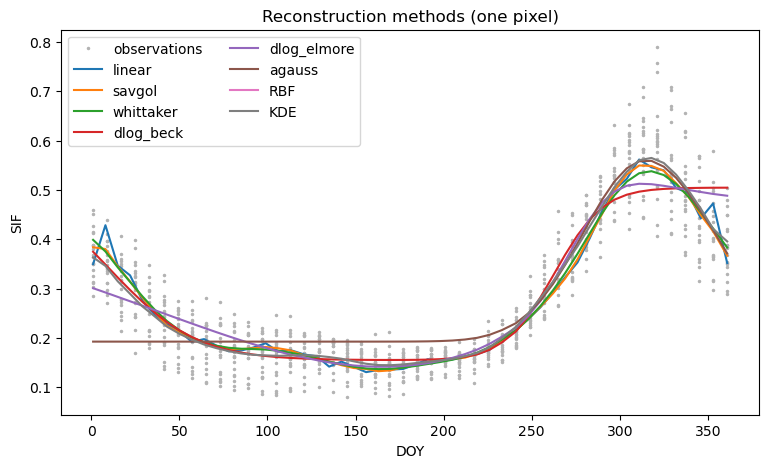

In [4]:
pixel = sif.isel(y=ys, x=xs)
one = sif.isel(y=slice(ys, ys + 1), x=slice(xs, xs + 1))
plt.figure(figsize=(9, 5))
plt.plot(pixel.doy.values, pixel.values, ".", ms=3, color="0.7", label="observations")
for method in ["linear", "savgol", "whittaker", "dlog_beck", "dlog_elmore", "agauss", "RBF", "KDE"]:
    try:
        s = one.pheno.PhenoShape(interpolType=method)
        plt.plot(s.doy.values, s.isel(y=0, x=0).values, label=method)
    except Exception as e:
        print(f"{method}: {type(e).__name__}: {e}")
plt.legend(ncol=2); plt.xlabel("DOY"); plt.ylabel("SIF")
plt.title("Reconstruction methods (one pixel)"); plt.show()

Per-method parameters are passed through **`recon_params`** (a dict), so the
single `PhenoShape(interpolType=..., recon_params={...})` signature covers every
method. E.g. `savgol` takes `window_length` / `polyorder`, and `whittaker` takes
the smoothing strength `lmbd` (larger ⇒ smoother):

In [5]:
s_sg = one.pheno.PhenoShape(interpolType="savgol", recon_params={"window_length": 11, "polyorder": 3})
s_wh = one.pheno.PhenoShape(interpolType="whittaker", recon_params={"lmbd": 50.0})
print("recon_params OK:", dict(s_sg.sizes), dict(s_wh.sizes))

recon_params OK: {'doy': 52, 'y': 1, 'x': 1} {'doy': 52, 'y': 1, 'x': 1}


## 3. Land-surface phenology metrics — `PhenoLSP`

`PhenoLSP` reads a `PhenoShape` curve and returns the **18 LSP metrics** per pixel
as a `Dataset`. Timing metrics are in DOY; value metrics are in the index's units
(here SIF). The peak (POS) is the curve maximum; SOS/EOS come from **axis 3**, the
`extraction` method.

| metric | meaning |
|---|---|
| `sos`, `pos`, `eos` | DOY of start / peak / end of season |
| `vsos`, `vpos`, `veos` | curve value at SOS / POS / EOS (`vpos` = seasonal max) |
| `los` | length of season = `eos − sos` (days) |
| `msp`, `mau` | DOY midway through green-up (spring) and senescence (autumn) |
| `vmsp`, `vmau` | curve value at `msp` / `mau` |
| `ampl` | amplitude = `vpos − trough` |
| `ios` | integral of the season (area under the curve, SOS→EOS) |
| `rog`, `ros` | rate of greening (SOS→POS) and senescence (POS→EOS) — slopes |
| `sw` | skewness of the growing-season curve |
| `trough` | trough / base value (the curve minimum) |
| `mos` | middle of season (DOY midpoint between SOS and EOS) |

**`extraction`** chooses how SOS/EOS are located — the four methods can give very
different DOYs on the *same* curve (see the printout):

- `seasonal_median` — historical default; median DOY of the green-up / senescing
  phase around the peak.
- `trs` — relative-amplitude **threshold** (default 50 %); pass
  `extract_params={"threshold": 0.2}` for 20 %.
- `der` — **derivative**: SOS/EOS at the maximum greening / senescence rate.
- `curvature` — **inflection**: SOS/EOS at the maximum curvature on each side.

Method-specific options go through **`extract_params`**, mirroring `recon_params`.

In [6]:
lsp = shape.pheno.PhenoLSP()
print(list(lsp.data_vars))

['sos', 'pos', 'eos', 'vsos', 'vpos', 'veos', 'los', 'msp', 'mau', 'vmsp', 'vmau', 'ampl', 'ios', 'rog', 'ros', 'sw', 'trough', 'mos']


In [7]:
for extraction in list_extractors():
    l = shape.pheno.PhenoLSP(extraction=extraction)
    print(f"{extraction:16s} median SOS={float(l['sos'].median()):5.0f}  median EOS={float(l['eos'].median()):5.0f}")
_ = shape.pheno.PhenoLSP(extraction="trs", extract_params={"threshold": 0.2})
print("extract_params OK")

curvature        median SOS=   40  median EOS=  339


der              median SOS=  283  median EOS=  361


seasonal_median  median SOS=  241  median EOS=  339


trs              median SOS=    1  median EOS=  361


extract_params OK


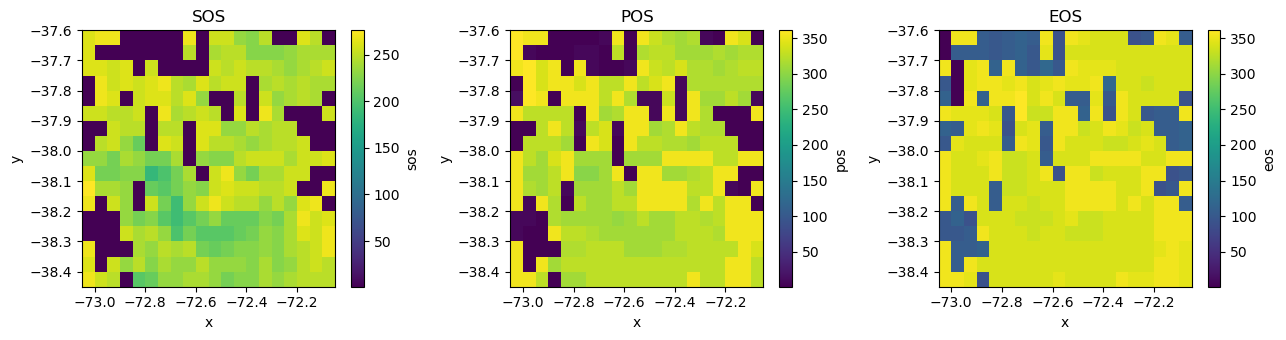

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, m in zip(axes, ["sos", "pos", "eos"]):
    lsp[m].plot(ax=ax); ax.set_title(m.upper())
plt.tight_layout(); plt.show()

## 4. Goodness of fit — `RMSE`

`RMSE` measures, per pixel, how well the reconstructed curve matches the original
observations — use it to compare reconstruction methods or flag poorly-fit pixels.

- **`normalized=True`** → nRMSE (RMSE ÷ value range), comparable across pixels and
  indices.
- **`segment=True`** → splits the error by phenophase, adding `rmse_sos`,
  `rmse_pos`, `rmse_eos` next to the overall `rmse`, showing *where* in the season
  the fit struggles (it reads the breakpoints from the `LSP_stack` you pass in).

In [9]:
rmse = shape.pheno.RMSE(sif, LSP_stack=lsp, normalized=True)
print("overall nRMSE (mean):", float(rmse["rmse"].mean()))
seg = shape.pheno.RMSE(sif, LSP_stack=lsp, normalized=True, segment=True)
print("segmented variables :", list(seg.data_vars))

overall nRMSE (mean): 0.06927432388897184
segmented variables : ['rmse', 'rmse_sos', 'rmse_pos', 'rmse_eos']


## 5. Curvature — `get_curvature` / `classify_vector_numeric`

`classify_vector_numeric(v)` reduces a curve to a single number — the **sum of its
second differences** (`np.sum(np.diff(v, n=2))`), a coarse measure of overall
concavity. `get_curvature` applies it across the `doy` axis to produce **one value
per pixel** `(y, x)`: a map of how strongly curved (vs. flat/linear) each pixel's
seasonal shape is. *(This whole-season summary is distinct from the finer
`curvature` extractor in §3, which uses the second derivative to locate SOS/EOS.)*

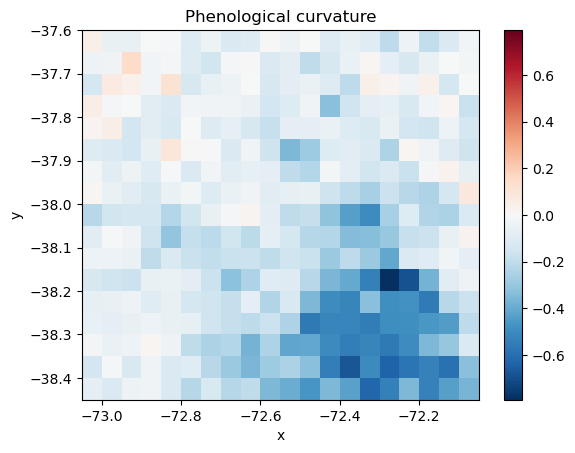

classify_vector_numeric (central pixel): -0.19955235347151756


In [10]:
curv = get_curvature(shape)
curv.plot(); plt.title("Phenological curvature"); plt.show()
print("classify_vector_numeric (central pixel):",
      float(classify_vector_numeric(shape.isel(y=ys, x=xs).values)))

## 6. Number of seasons — `n_seasons` (NOS)

`n_seasons` counts the **growing cycles per pixel** (NOS, *Number Of Seasons*) by
detecting peaks of the reconstructed `PhenoShape` curve with
`scipy.signal.find_peaks`. It separates single-cycle vegetation (NOS = 1) from
**multi-cropping / bimodal** systems (NOS ≥ 2), e.g. double-cropped cereals.

What makes a peak count:
- **`prominence`** (default `0.1`) — a peak must stand at least this fraction of
  the pixel's amplitude (max − min) above its surroundings. This is the main noise
  filter: raise it to keep only the strong seasons, lower it to be more permissive.
- **`distance`** — optional minimum spacing between peaks, in samples of the `doy`
  grid (forbid peaks closer than, say, ~2 months).
- **`min_height`** — optional minimum peak height, as a fraction of amplitude above
  the trough.

Edge cases: a flat curve (amplitude ≤ 0) → `0`; fewer than 3 finite values → `NaN`.
The output is a per-pixel `(y, x)` count. The bundled samples are largely
single-season, so this mostly returns `1` here — see §14 for the data needed to
exercise NOS ≥ 2.

season counts present: [0. 1. 2. 3. 4.]


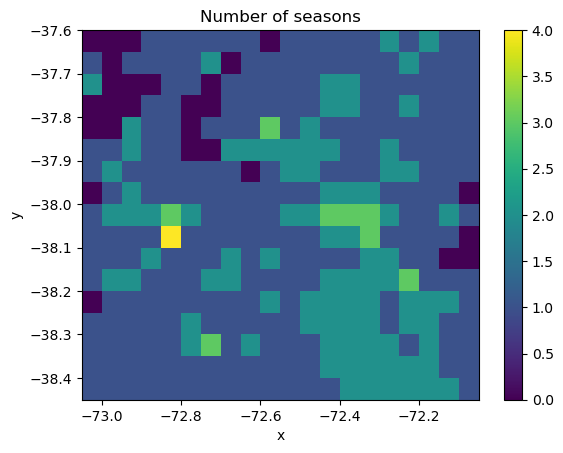

In [11]:
nos = n_seasons(shape, prominence=0.1)
print("season counts present:", np.unique(nos.values[np.isfinite(nos.values)]))
nos.plot(); plt.title("Number of seasons"); plt.show()

## 7. Southern-Hemisphere reordering — `reorder_southern_hemisphere`

SIF is over Chile: the austral growing season peaks around the calendar-year
boundary (Dec–Feb), so on a normal day-of-year axis it is **split** across DOY
365/1. `reorder_southern_hemisphere` re-sorts the time steps to start the
"season" in July and **re-labels `doy` as a day-of-season index — still 1–365,
but starting mid-year** — so the season becomes contiguous and centred.

That is why the middle panel below still spans 1–365: it is *day of season*,
not calendar day. To put the *real* Southern-Hemisphere calendar DOY
(…183, 365, 1, 182…) back on the axis, use `plot_with_southern_doy` on the
reordered shape. (Run on a 2-year slice for speed.)

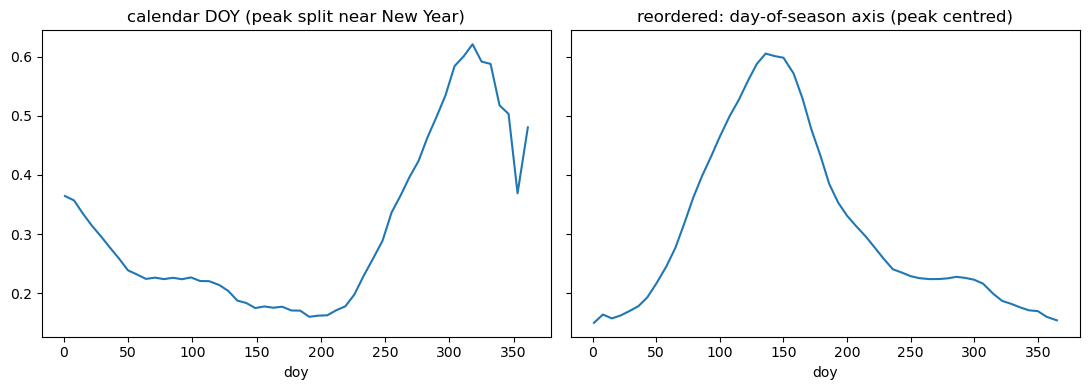

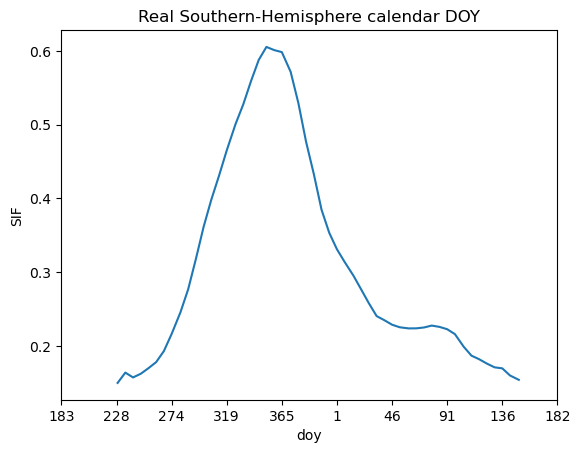

reordered DOY positions: 92


In [12]:
from phenosensing.plotting import plot_with_southern_doy

sif_2y = sif.isel(time=slice(0, 92))
positions, sif_sh = reorder_southern_hemisphere(sif_2y)
sh_shape = sif_sh.pheno.PhenoShape()

# Before/after: calendar DOY splits the austral peak; reordering centres it.
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
sif_2y.pheno.PhenoShape().isel(y=ys, x=xs).plot(ax=axes[0])
axes[0].set_title("calendar DOY (peak split near New Year)")
sh_shape.isel(y=ys, x=xs).plot(ax=axes[1])
axes[1].set_title("reordered: day-of-season axis (peak centred)")
plt.tight_layout(); plt.show()

# Same reordered curve, x-axis re-labelled to the real SH calendar DOY
try:
    plot_with_southern_doy(sh_shape, (float(sif.x[xs]), float(sif.y[ys])),
                           ylabel="SIF", title="Real Southern-Hemisphere calendar DOY")
    plt.show()
except Exception as e:
    print("plot_with_southern_doy:", type(e).__name__, e)
print("reordered DOY positions:", len(positions))

## 8. Interannual time series — `get_timeseries_metrics`

This is the **temporal axis**, and PhenoSensing's signature feature. Instead of pooling
all years into one climatology, it slides a **moving multi-year window** over the
series: for each window it runs the full reconstruct → extract pipeline and records
every metric, producing a *time series* of each LSP metric (one value per window
step). That series is what feeds the trend in §9. Run on a small spatial subset
here for speed.

- **`window_length`** — number of years pooled per step (e.g. `3`); `1` gives a
  per-year estimate.
- **`metric`** — `"all"` or a subset, e.g. `["sos", "pos", "eos"]`.
- **`interpolType` / `recon_params` / `extraction` / `extract_params`** — the same
  axis-1 and axis-3 knobs as `PhenoShape` / `PhenoLSP`, applied inside every window.

Returns a `dict` of `(time, y, x)` `DataArray`s, one per requested metric.

{'sos': {'time': 18, 'y': 4, 'x': 4}, 'pos': {'time': 18, 'y': 4, 'x': 4}, 'eos': {'time': 18, 'y': 4, 'x': 4}}


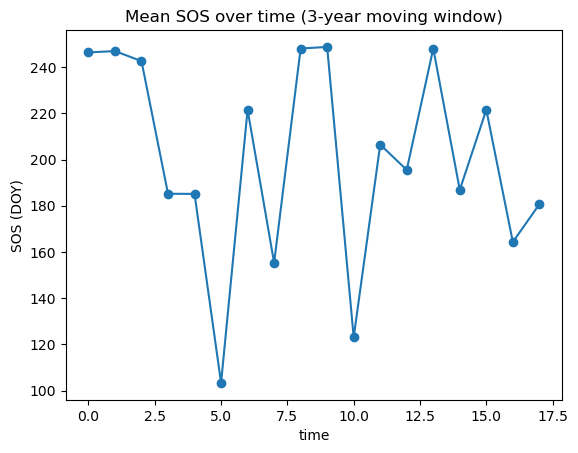

In [13]:
sif_small = sif.isel(y=slice(ys - 2, ys + 2), x=slice(xs - 2, xs + 2))
ts = sif_small.pheno.get_timeseries_metrics(window_length=3, metric=["sos", "pos", "eos"], nGS=40)
print({k: dict(v.sizes) for k, v in ts.items()})
ts["sos"].mean(dim=["y", "x"]).plot(marker="o")
plt.title("Mean SOS over time (3-year moving window)"); plt.ylabel("SOS (DOY)"); plt.show()

## 9. Trends — `trend` (Theil–Sen slope + Mann–Kendall)

`trend` fits a **robust** per-pixel temporal trend to any metric series from §8
(or any `(time, y, x)` array). It returns a `Dataset` with:

- **`slope`** — the **Theil–Sen** estimator (median of pairwise slopes), in metric
  units per time step; robust to outliers. For `sos`, a negative slope means the
  season is starting *earlier* over time.
- **`p_value`** — the two-sided **Mann–Kendall** significance (a non-parametric
  monotonic-trend test).

Pixels with fewer than four finite time steps return `NaN`.

slope range (DOY/step): -1.125 0.6923076923076923


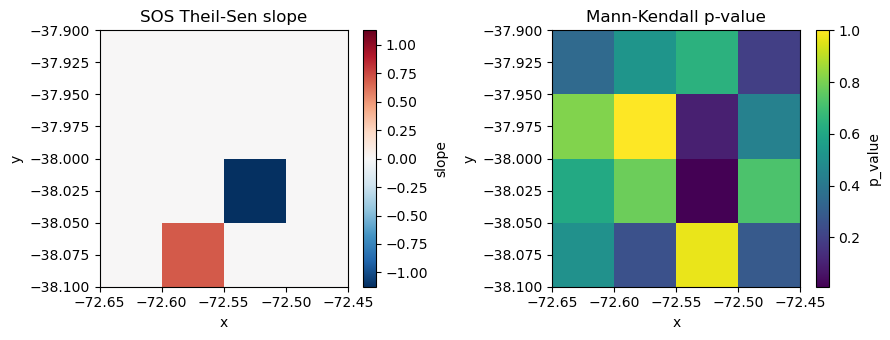

In [14]:
sos_trend = trend(ts["sos"])
print("slope range (DOY/step):", float(sos_trend["slope"].min()), float(sos_trend["slope"].max()))
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
sos_trend["slope"].plot(ax=axes[0]); axes[0].set_title("SOS Theil-Sen slope")
sos_trend["p_value"].plot(ax=axes[1]); axes[1].set_title("Mann-Kendall p-value")
plt.tight_layout(); plt.show()

## 10. Anomalies — `anomaly` (npphen-style RFD)

`anomaly` compares each observation against the pixel's **climatological**
`PhenoShape`: it interpolates the expected value at every observation's DOY and
measures the departure from it. Returns a `Dataset` with:

- **`anomaly`** — observed − expected, in index units.
- **`rfd`** — the empirical percentile (RFD) of each anomaly within the pixel's own
  distribution, in (0, 1]; npphen-style.
- **`z`** — the standardized anomaly (when `standardize=True`).

Pass **`reference=`** a held-out cube to score a target period against an
independent climatology; `interpolType="KDE"` builds a fully non-parametric
reference. (Here it self-references the 20-year SIF.)

variables: ['anomaly', 'rfd', 'z']


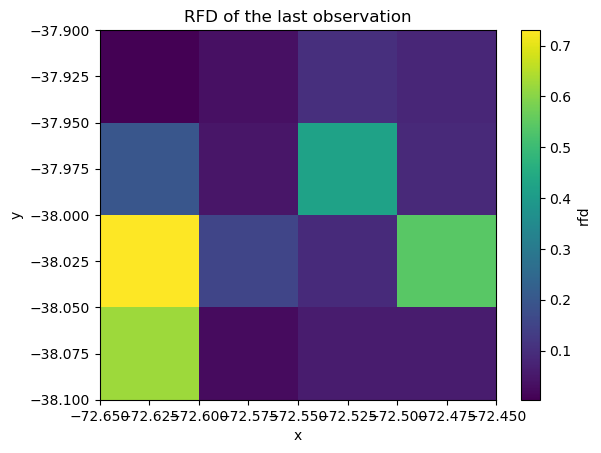

In [15]:
an = anomaly(sif_small, nGS=40)
print("variables:", list(an.data_vars))
an["rfd"].isel(time=-1).plot(); plt.title("RFD of the last observation"); plt.show()

## 11. Per-metric uncertainty — `uncertainty` (bootstrap)

`uncertainty` estimates how stable each LSP metric is to sampling noise: it
**bootstraps** the per-pixel observations `n_boot` times, recomputes the 16 metrics
on each resample, and returns the **standard deviation** of each metric per pixel
(`(y, x)` per variable). Larger values flag metrics/pixels whose timing or
magnitude is poorly constrained by the available observations.

- **`n_boot`** — number of bootstrap replicates (default 50).
- **`interpolType` / `rollWindow` / `nGS` / `extraction` / `extract_params`** — the
  same pipeline knobs, applied to every replicate.
- **`seed`** — makes the resampling reproducible.

In [16]:
unc = uncertainty(sif_small, n_boot=20, nGS=40)
print("mean SOS uncertainty (std, days):", float(unc["sos"].mean()))

mean SOS uncertainty (std, days): 52.690804515074525


## 12. Performance — chunking / out-of-core + Numba

`PhenoShape` is built on `xr.apply_ufunc(dask="parallelized")`, so passing
**`chunks=`** returns a lazy, **Dask-backed** result that computes tile-by-tile —
the same numbers as the eager path, but without holding the whole cube in memory
(verified below). For the in-memory **linear** path it also uses a **Numba** kernel
(`[fast]` extra) for a large speed-up. **`computeChunkSize`** suggests a tile shape
bounded by a target size in MB.

In [17]:
from phenosensing.utils import computeChunkSize
print("suggested chunks (~5 MB):", computeChunkSize(sif, sizeMB=5))
lazy = sif.pheno.PhenoShape(chunks={"x": 10, "y": 10})
print("dask-backed     :", dask.is_dask_collection(lazy.data))
print("chunked == eager:", bool(np.allclose(lazy.compute().values, shape.values, equal_nan=True)))

suggested chunks (~5 MB): {'time': 920, 'y': 17, 'x': 20}
dask-backed     : True


chunked == eager: True


## 13. Plotting helpers

`PhenoPlot` overlays the **per-year observations** on the fitted curve for one
pixel — a quick visual check of the reconstruction and of interannual spread.

- **`southern=True`** re-labels the x-axis to Southern-Hemisphere day-of-year so
  the austral season is centred (continuous across the calendar-year boundary).
- with **more than `many_years`** years it switches from a per-year legend to a
  continuous **palette + colorbar** (as for the 20-year SIF below).

`display_map` returns an interactive `folium` map of the data's bounding box
(needs the `[plot]` extra: folium, pyproj).

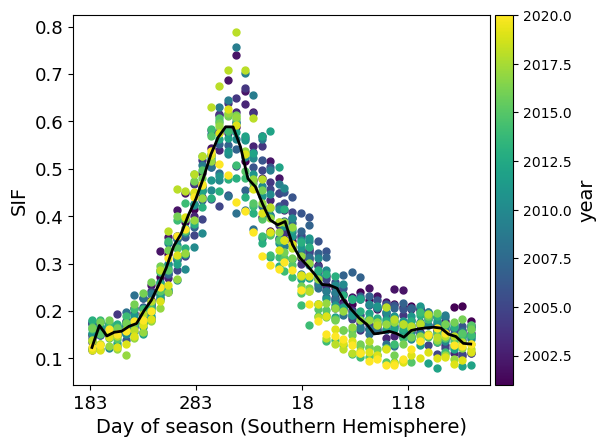

In [18]:
from phenosensing.plotting import PhenoPlot, display_map
try:
    # SIF spans 20 years -> continuous palette + colorbar; southern=True centres the austral season
    PhenoPlot(sif, X=float(sif.x[xs]), Y=float(sif.y[ys]), rollWindow=5, ylab="SIF", southern=True)
    plt.show()
except Exception as e:
    print("PhenoPlot:", type(e).__name__, e)

In [19]:
try:
    m = display_map((float(sif.x.min()), float(sif.x.max())),
                    (float(sif.y.min()), float(sif.y.max())))
    print("display_map -> folium.Map created (interactive; renders in a live notebook)")
except Exception as e:
    print("display_map needs the [plot] extra (folium, pyproj):", type(e).__name__, e)

display_map -> folium.Map created (interactive; renders in a live notebook)


## 14. What the bundled data cannot cover (and data needed)

The two bundled rasters are small and clean, so some capabilities can only be
*demonstrated* here, not stress-tested. To fully validate:

- **Large-scale / out-of-core performance.** The samples are tiny
  (≤ 920 × 17 × 20). Benchmarking Dask out-of-core and the Numba kernel at scale
  needs a large multi-tile stack (regional/continental MODIS/Landsat/Sentinel
  NDVI–EVI, GB-sized). The repo's `kndvi_186.tif` (57 × 48, 397 bands) is bigger
  but ships **without a matching date file** (`dates.txt` has 798 entries ≠ 397
  bands) — supply its acquisition dates to use it.
- **Northern-Hemisphere phenology.** Both samples are mid/low-latitude and SIF
  is Southern Hemisphere. Contrasting `reorder_southern_hemisphere` against a
  clean single-peaked NH season needs a Northern-Hemisphere NDVI/EVI series
  (e.g. a temperate deciduous forest).
- **Multi-cropping / bimodal seasons.** The samples are largely single-season,
  so `n_seasons` mostly returns 1. Validating NOS ≥ 2 needs a double-cropping
  region (e.g. irrigated cereals/rice with two cycles per year).
- **Noise robustness & QA weighting.** The samples are fairly clean.
  Stress-testing the robust smoothers (Whittaker / Savitzky-Golay /
  double-logistic) and the *planned* QA-weighting feature needs raw,
  cloud-contaminated optical data **with a per-observation quality band**
  (MODIS MOD13 pixel-reliability, or Landsat/Sentinel-2 SCL/Fmask).
- **Anomaly skill against an independent reference.** `anomaly(target,
  reference=...)` is best validated with a held-out climatology and a
  *documented extreme year* (e.g. a known drought). The 20-year SIF supports a
  self-reference demo only.
- **Cross-sensor / harmonised series** (e.g. HLS Landsat + Sentinel-2) are out
  of scope of the samples but needed to test robustness across sensors.

**Not yet implemented (so not testable here):** QA/weight-updating
reconstruction and the extra metrics (explicit trough/base, middle-of-season).
Both are on the roadmap; once added they need the QA-band data above and a
refresh of the golden regression fixtures.
